In [1]:
!pip install -q pandas scikit-learn matplotlib ipywidgets openpyxl

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.6 MB/s eta 0:00:00


In [2]:
data = {
    "query": [
        "Is Priya present",
        "Is Kumar present",
        "Is Priya mam in college",
        "Where is Priya mam",
        "Where is Kumar sir",
        "Which room is Priya in",
        "Who teaches DBMS",
        "Who teaches Python",
        "Who is the DBMS faculty",
        "When is Priya class",
        "What is Kumar timetable",
        "When can I meet Priya",
        "When is Priya free",
        "DBMS doubt who can help",
        "Who is available for DBMS",
        "Python doubt who can help",

        "Priya mam present ah",
        "Priya mam enga irukanga",
        "DBMS yaaru teach panranga",
        "Priya mam eppo free",
        "Enakku DBMS doubt irukku"
    ],

    "intent": [
        "attendance",
        "attendance",
        "attendance",
        "location",
        "location",
        "location",
        "subject",
        "subject",
        "subject",
        "schedule",
        "schedule",
        "availability",
        "availability",
        "available_faculty",
        "available_faculty",
        "available_faculty",

        "attendance",
        "location",
        "subject",
        "availability",
        "available_faculty"
    ]
}

df = pd.DataFrame(data)

df

,query,intent
0,Is Priya present,attendance
1,Is Kumar present,attendance
2,Is Priya mam in college,attendance
3,Where is Priya mam,location
4,Where is Kumar sir,location
5,Which room is Priya in,location
6,Who teaches DBMS,subject
7,Who teaches Python,subject
8,Who is the DBMS faculty,subject
9,When is Priya class,schedule


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df["query"],
    df["intent"],
    test_size=0.25,
    random_state=42
)

model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("ml", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [4]:
prediction = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    prediction
)

print("ML Model Accuracy:",
      round(accuracy * 100, 2), "%")

ML Model Accuracy: 33.33 %


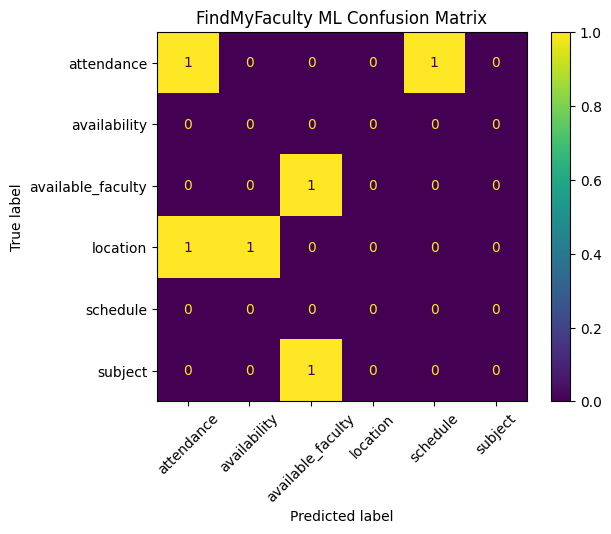

In [7]:
cm = confusion_matrix(
    y_test,
    prediction,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(
    xticks_rotation=45
)

plt.title("FindMyFaculty ML Confusion Matrix")
plt.show()

In [8]:
faculty = pd.DataFrame({

    "name": [
        "Priya",
        "Kumar",
        "Anitha",
        "Divya"
    ],

    "subject": [
        "DBMS",
        "Python",
        "Machine Learning",
        "Computer Networks"
    ],

    "status": [
        "Present",
        "Present",
        "Absent",
        "Present"
    ],

    "room": [
        "Room 204",
        "Room 301",
        "Room 205",
        "Room 302"
    ]
})

faculty

,name,subject,status,room
0,Priya,DBMS,Present,Room 204
1,Kumar,Python,Present,Room 301
2,Anitha,Machine Learning,Absent,Room 205
3,Divya,Computer Networks,Present,Room 302


In [9]:
def find_faculty(question):

    intent = model.predict([question])[0]

    q = question.lower()

    print("\n-----------------------------")
    print("FindMyFaculty AI")
    print("-----------------------------")

    print("Question :", question)
    print("Intent   :", intent)

    # Find faculty
    person = None

    for name in faculty["name"]:

        if name.lower() in q:
            person = name

    # Attendance
    if intent == "attendance":

        if person:

            row = faculty[
                faculty["name"] == person
            ].iloc[0]

            print("\n👨‍🏫 Faculty :", person)
            print("Status     :", row["status"])

        else:

            print("Please mention faculty name.")

    # Location
    elif intent == "location":

        if person:

            row = faculty[
                faculty["name"] == person
            ].iloc[0]

            print("\n👨‍🏫 Faculty :", person)
            print("📍 Probable Room :", row["room"])
            print("Status           :", row["status"])

        else:

            print("Please mention faculty name.")

    # Subject
    elif intent == "subject":

        for _, row in faculty.iterrows():

            if row["subject"].lower() in q:

                print(
                    "\n📚",
                    row["subject"],
                    "is handled by",
                    row["name"]
                )

    # Availability
    elif intent == "availability":

        if person:

            row = faculty[
                faculty["name"] == person
            ].iloc[0]

            print(
                "\n👨‍🏫",
                person,
                "Status:",
                row["status"]
            )

            if row["status"] == "Present":
                print("🟢 Faculty is likely available.")
            else:
                print("🔴 Faculty is absent.")

        else:

            print("Please mention faculty name.")

    # Available faculty
    elif intent == "available_faculty":

        found = False

        for _, row in faculty.iterrows():

            if row["subject"].lower() in q:

                found = True

                if row["status"] == "Present":

                    print(
                        "\n🟢",
                        row["name"],
                        "can help with",
                        row["subject"]
                    )

                else:

                    print(
                        "\n🔴",
                        row["name"],
                        "is absent."
                    )

        if not found:
            print("No matching faculty found.")

    print("-----------------------------")

In [10]:
find_faculty(
    "Is Priya present"
)


-----------------------------
FindMyFaculty AI
-----------------------------
Question : Is Priya present
Intent   : attendance

👨‍🏫 Faculty : Priya
Status     : Present
-----------------------------


In [11]:
find_faculty(
    "Where is Priya mam"
)


-----------------------------
FindMyFaculty AI
-----------------------------
Question : Where is Priya mam
Intent   : location

👨‍🏫 Faculty : Priya
📍 Probable Room : Room 204
Status           : Present
-----------------------------


In [13]:
find_faculty(
    "Priya mam enga irukanga"
)


-----------------------------
FindMyFaculty AI
-----------------------------
Question : Priya mam enga irukanga
Intent   : availability

👨‍🏫 Priya Status: Present
🟢 Faculty is likely available.
-----------------------------


In [14]:
find_faculty(
    "Priya mam present ah"
)


-----------------------------
FindMyFaculty AI
-----------------------------
Question : Priya mam present ah
Intent   : attendance

👨‍🏫 Faculty : Priya
Status     : Present
-----------------------------


In [15]:
find_faculty(
    "Enakku DBMS doubt irukku"
)


-----------------------------
FindMyFaculty AI
-----------------------------
Question : Enakku DBMS doubt irukku
Intent   : available_faculty

🟢 Priya can help with DBMS
-----------------------------


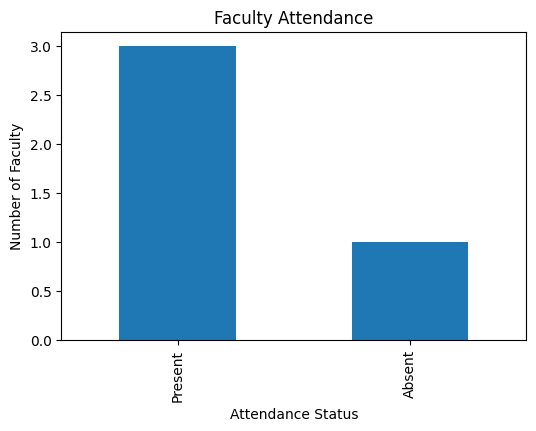

In [16]:
faculty["status"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Faculty Attendance")
plt.xlabel("Attendance Status")
plt.ylabel("Number of Faculty")

plt.show()

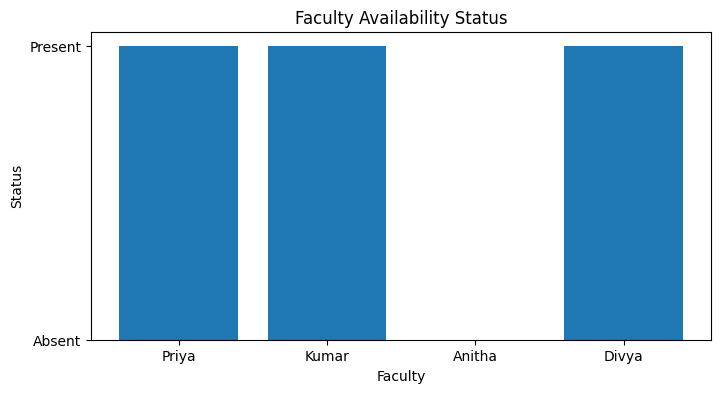

In [17]:
available = faculty["status"].map({
    "Present": 1,
    "Absent": 0
})

plt.figure(figsize=(8, 4))

plt.bar(
    faculty["name"],
    available
)

plt.yticks(
    [0, 1],
    ["Absent", "Present"]
)

plt.title(
    "Faculty Availability Status"
)

plt.xlabel("Faculty")
plt.ylabel("Status")

plt.show()

In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output

question_box = widgets.Text(
    placeholder="Ask your question...",
    description="Question:"
)

button = widgets.Button(
    description="🤖 Ask AI",
    button_style="primary"
)

output = widgets.Output()


def ask_ai(button):

    with output:

        clear_output()

        find_faculty(
            question_box.value
        )


button.on_click(ask_ai)

display(question_box)
display(button)
display(output)

Text(value='', description='Question:', placeholder='Ask your question...')

Button(button_style='primary', description='🤖 Ask AI', style=ButtonStyle())

Output()